In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.notebook import tqdm
import os

import dataset
import network
import nonlinearity
import train_network

plt.ioff()

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

Text(0.5, 1.0, 'Loss versus number of samples, log axes')

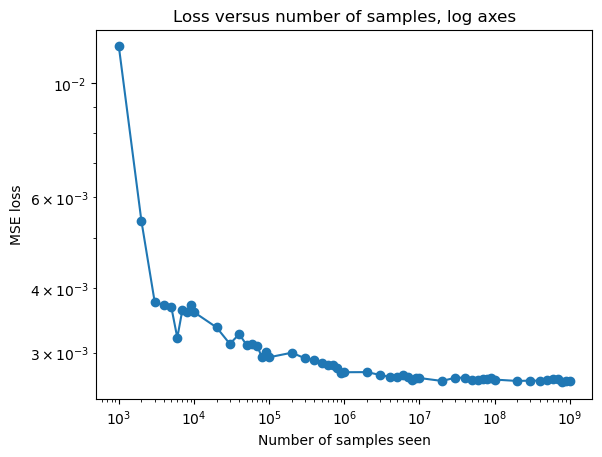

In [3]:
samples = np.load('net_checkpoints/samples.npy')
losses = np.load('net_checkpoints/losses.npy')
plt.loglog(samples, losses, marker='o')
plt.xlabel('Number of samples seen')
plt.ylabel('MSE loss')
plt.title('Loss versus number of samples, log axes')

In [4]:
scheduler = train_network.Scheduler()
network_shape = [3, 100, 100, 100, 2]

grid_points = 400
vec_grid_points = 20
hist_points = 100000
num_colors = max(network_shape)
colors = []
for i in range(num_colors):
    colors.append((np.random.uniform(0, 1), np.random.uniform(0, 1), np.random.uniform(0, 1)))
data_range = [-3, 3]


net = network.Network(network_shape, scheduler).to(device)
checkpoint = torch.load('network_final.pt', map_location=device)
net.load_state_dict(checkpoint['weights'])
net.eval();

(1, 5)


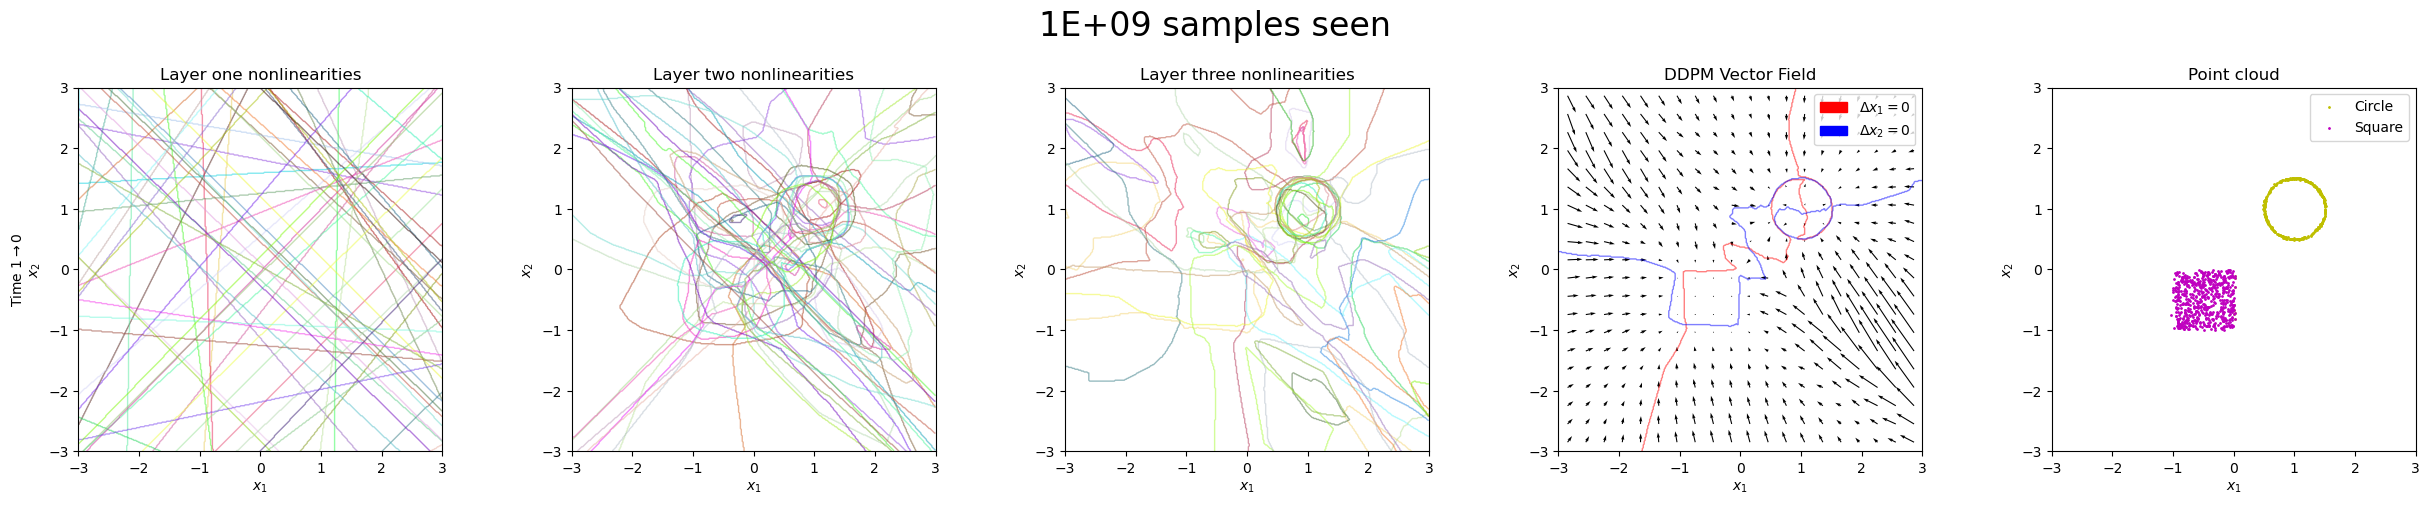

In [10]:
plotter = nonlinearity.Animator(net, colors, scheduler, data_range, 
                             grid_points, vec_grid_points, 
                             hist_points, device, is_DDPM=True)
plotter.draw_small(1e9, times=[0])
plt.show()

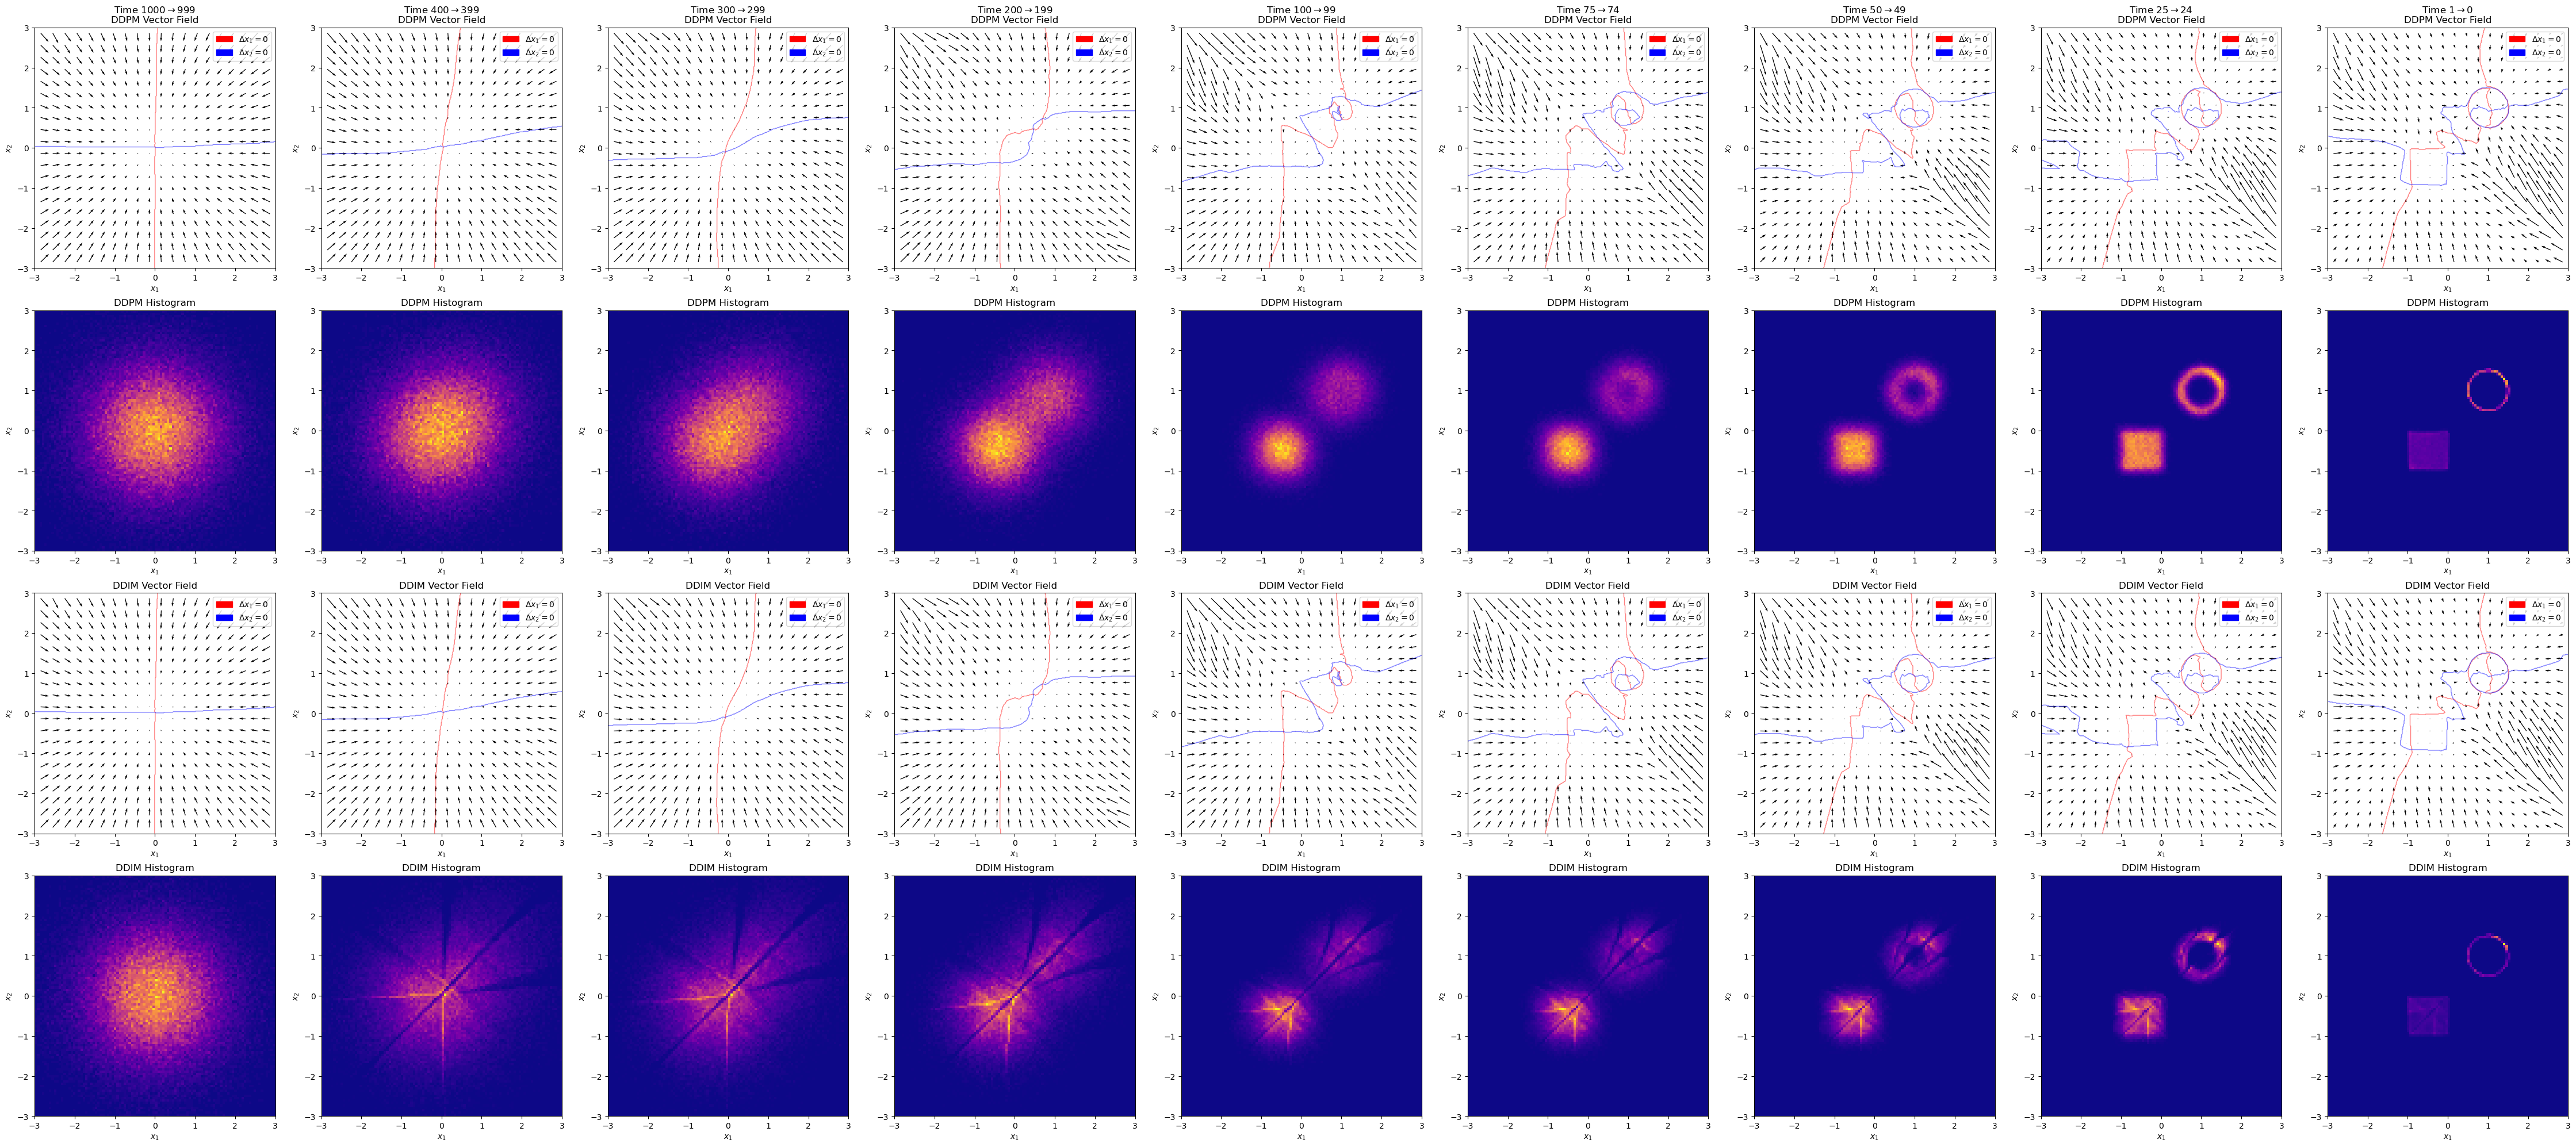

In [6]:
def plot_vec_hist(axs, times, row, column, plotter, DD_label):
    if row == 0:
        axs[row, column].set_title(f'Time ${times[column]+1}\\to{times[column]}$\n{DD_label} Vector Field')
    else:
        axs[row, column].set_title(f'{DD_label} Vector Field')
    axs[row, column].quiver(plotter.X_vec, plotter.Y_vec, plotter.vec_field[:, :, 0], plotter.vec_field[:, :, 1])
    nonlinearity.plot_nullclines(plotter.X, plotter.Y, plotter.nullclines, axs[row, column])
    
    
    axs[row+1,column].set_title(f'{DD_label} Histogram')
    axs[row+1,column].hist2d(plotter.point_locs[:, 0], plotter.point_locs[:, 1], 
                             bins=100, cmap='plasma', range=[plotter.data_range, plotter.data_range])

times = [999, 399, 299, 199, 99, 74, 49, 24, 0]

fig = plt.figure(figsize=(5*len(times), 5*4))
axs = fig.subplots(4, len(times))

for ax in fig.axes:
    ax.set_ylim([-3, 3])
    ax.set_xlim([-3, 3])
    ax.set_aspect('equal')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')


plotter_DDPM = nonlinearity.Animator(net, colors, scheduler, data_range, 
                                     grid_points, vec_grid_points, 
                                     hist_points, device, is_DDPM=True)

plotter_DDIM = nonlinearity.Animator(net, colors, scheduler, data_range, 
                                     grid_points, vec_grid_points, 
                                     hist_points, device, is_DDPM=False)

for i in range(len(times)):
    plotter_DDPM.calculate(times[i])
    plotter_DDIM.calculate(times[i])
    plot_vec_hist(axs, times, 0, i, plotter_DDPM, 'DDPM')
    plot_vec_hist(axs, times, 2, i, plotter_DDIM, 'DDIM')
    

fig.tight_layout()

Temporary testing of DDIM versus DDPM vector field differences

In [21]:
abar = np.insert(scheduler.alphabars, 0, 1)

In [27]:
sigma_square = ((1 - abar[:-1])/(1 - abar[1:])*scheduler.betas)

In [28]:
DDPM = 1 - abar[:-1]

In [29]:
DDIM = 1 - abar[:-1] - sigma_square

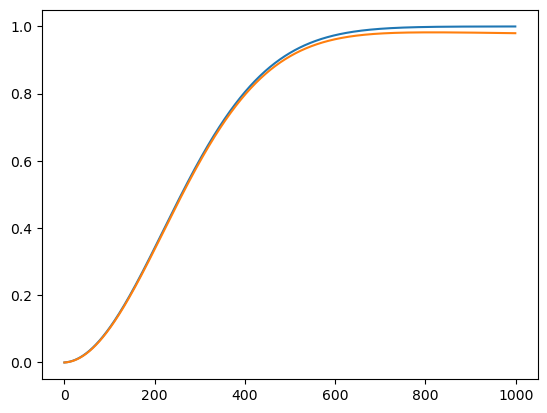

In [32]:
plt.plot(DDPM)
plt.plot(DDIM)

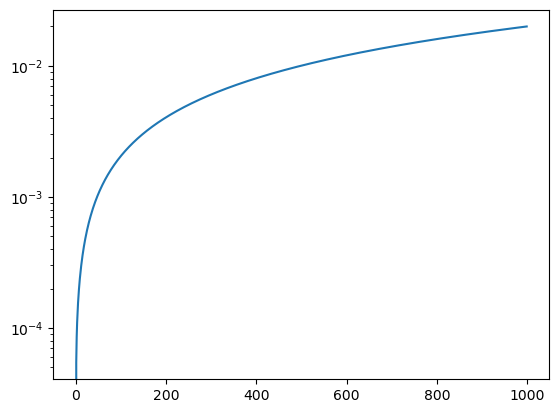

In [33]:
plt.semilogy(DDPM - DDIM)